In [1]:
# =========================
# Structure Separation Distance Density (SSDD) PARAMETERS 
# =========================

INPUT_PATH = r"C:\Users\shoang12\OneDrive - Cal Poly\SSDD\SLO_Building_Subset\Buildings.shp"   # SHP / GPKG / GeoJSON / FGDB (layer required)
INPUT_LAYER = None                      # e.g. "buildings" for GPKG/FGDB, else None

OUT_DIR = r"C:\Users\shoang12\OneDrive - Cal Poly\SSDD\output"
RUN_NAME = "SLO_sample"

# California statewide equal-area projection in meters
TARGET_EPSG = 3310  # NAD83 / California Albers

# ---------- SD knobs ----------
r_D = 100.0          # meters; buffer distance around EACH footprint for SD window
alpha_D = 0.5        # 1 = kernel only, 0 = basal only
kernel_type = "quartic"
weight_by_area = False  # True => w_j=area, False => w_j=1

# ---------- SS knobs ----------
r_S = 50.0           # meters; neighbor search radius for separation
epsilon = 0.5        # meters; distance floor
sigma_theta = 15.0   # degrees; smaller => orientation matters more
alpha_S = 0.5        # 1 = distance-only, 0 = distance+orientation only

# ---------- Master blend ----------
beta = 0.5           # 1 = SD only, 0 = SS only

# ---------- Normalization ----------
NORM_METHOD = "robust"  # "minmax" or "robust"
P_LOW, P_HIGH = 2, 98

# ---------- QA ----------
MAKE_QA_PLOTS = True

print("SD knobs" + ", r_D: " + str(r_D) + ", alpha_D: " + str(alpha_D) + ", kernel_type: " + str(kernel_type) + ", weight_by_area: " + str(weight_by_area))
#print("SS knobs:" + r_S, epsilon, sigma_theta, alpha_S)

SD knobs, r_D: 100.0, alpha_D: 0.5, kernel_type: quartic, weight_by_area: False


In [2]:
#Imports + utilities (don’t edit)

import os, math, time
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from shapely import STRtree

import geopandas as gpd
bld = gpd.read_file(r"C:\Users\shoang12\OneDrive - Cal Poly\SSDD\SLO_Building_Subset\Buildings.shp")
print(len(bld))
print(bld.geometry.iloc[0])


def read_buildings(path: str, layer: str | None):
    if layer is None:
        return gpd.read_file(path)
    return gpd.read_file(path, layer=layer)

def ensure_projected_meters(gdf: gpd.GeoDataFrame, target_epsg: int) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        raise ValueError(
            "Input has no CRS defined. Define it in QGIS (Layer Properties → Source) first."
        )
    if gdf.crs.to_epsg() != target_epsg:
        gdf = gdf.to_crs(epsg=target_epsg)
    return gdf

def norm_series(x: pd.Series, method="minmax", p_low=2, p_high=98) -> pd.Series:
    x = x.astype(float)
    if method == "minmax":
        lo, hi = np.nanmin(x), np.nanmax(x)
        if hi == lo:
            return pd.Series(np.zeros(len(x)), index=x.index)
        return (x - lo) / (hi - lo)

    if method == "robust":
        lo, hi = np.nanpercentile(x, p_low), np.nanpercentile(x, p_high)
        if hi == lo:
            return pd.Series(np.zeros(len(x)), index=x.index)
        x_clip = np.clip(x, lo, hi)
        return (x_clip - lo) / (hi - lo)

    raise ValueError("Unknown normalization method")

def quartic_kernel(u: float) -> float:
    # K(u) = (1 - u^2)^2 for u in [0,1], else 0
    if u < 0 or u > 1:
        return 0.0
    return (1.0 - u*u)**2

def kernel_value(u: float, kernel="quartic") -> float:
    if kernel == "quartic":
        return quartic_kernel(u)
    raise ValueError("Unknown kernel type")

def dominant_orientation_degrees(poly) -> float:
    """
    Dominant orientation proxy: angle of the longest edge of the minimum rotated rectangle (MRR).
    Returns angle in [0, 180).
    """
    mrr = poly.minimum_rotated_rectangle
    coords = list(mrr.exterior.coords)

    edges = []
    for k in range(4):
        x1, y1 = coords[k]
        x2, y2 = coords[k+1]
        dx, dy = x2 - x1, y2 - y1
        length = math.hypot(dx, dy)
        edges.append((length, dx, dy))

    length, dx, dy = max(edges, key=lambda t: t[0])
    angle = math.degrees(math.atan2(dy, dx)) % 180.0
    return angle

def angle_difference_deg(a: float, b: float) -> float:
    diff = abs(a - b) % 180.0
    diff = min(diff, 180.0 - diff)
    return min(diff, 90.0)

def orientation_factor(theta_deg: float, sigma_theta: float) -> float:
    # g(theta) = exp(-(theta/sigma)^2)
    if sigma_theta <= 0:
        return 1.0
    return math.exp(- (theta_deg / sigma_theta)**2)

def qa_hist(series: pd.Series, title: str):
    plt.figure()
    plt.hist(series.dropna().values, bins=40)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("Count")
    plt.show()


C:\Users\shoang12\AppData\Local\uv\cache\archive-v0\Ka28MIqm8G7KkmmWsOnnf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


22974
POLYGON ((5762251.904687434 2309847.4886516184, 5762284.302844599 2309870.4546491355, 5762304.808039904 2309841.3371172994, 5762285.943290025 2309828.2136897296, 5762290.864536867 2309821.2418863326, 5762276.921026185 2309811.3993159235, 5762251.904687434 2309847.4886516184))


In [3]:
#Load + clean + reproject
t0 = time.time()
os.makedirs(OUT_DIR, exist_ok=True)

bld = read_buildings(INPUT_PATH, INPUT_LAYER)
bld = bld[bld.geometry.notnull()].copy()
bld = bld[bld.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# Fix common geometry issues
bld["geometry"] = bld["geometry"].buffer(0)

print("Input CRS:", bld.crs)
bld = ensure_projected_meters(bld, TARGET_EPSG)
print("Analysis CRS:", bld.crs)

# Add ID if missing
if "bld_id" not in bld.columns:
    bld["bld_id"] = np.arange(len(bld))

bld["bld_area"] = bld.geometry.area
bld["rep_pt"] = bld.geometry.representative_point()

print(f"Loaded {len(bld):,} buildings")


Input CRS: EPSG:2874
Analysis CRS: EPSG:3310
Loaded 22,974 buildings


In [4]:
#Orientation
tqdm.pandas(desc="Computing building orientation")
bld["phi_deg"] = bld.geometry.progress_apply(dominant_orientation_degrees)


Computing building orientation: 100%|█████████████████████████████████████████| 22974/22974 [00:00<00:00, 85835.56it/s]


In [5]:
# =========================
# Spatial indexes (STRtree)
# =========================
#
# This version is robust across Shapely 2.x behaviors:
# - Some builds return indices from STRtree.query(...)
# - Others may return geometries
#
# We normalize to ALWAYS return integer indices.
#

from shapely.strtree import STRtree
import numpy as np

# --- Source geometry arrays (keep as numpy arrays) ---
polys = bld.geometry.values                   # polygons
pts = bld["rep_pt"].values                    # representative points (one per building)

# --- Build STRtrees ---
tree_polys = STRtree(polys)
tree_pts   = STRtree(pts)

def tree_query_indices(tree: STRtree, query_geom):
    """
    Return a 1D numpy array of integer indices for candidates returned by STRtree.query().
    Works whether STRtree.query returns:
      - indices (preferred, Shapely 2.x), OR
      - geometries (fallback in some environments)
    """
    res = tree.query(query_geom)

    # If it already looks like indices, return as int array
    # (Common case: numpy array of dtype int)
    if isinstance(res, (list, tuple, np.ndarray)) and len(res) > 0:
        first = res[0]
        if isinstance(first, (int, np.integer)):
            return np.asarray(res, dtype=int)

    # Fallback: assume geometries returned; map to indices via object identity
    # Note: this works only if the returned objects are the same instances.
    # If you ever see a KeyError again, tell me and we’ll switch to query_bulk approach.
    idx_map = {id(g): i for i, g in enumerate(tree.geometries)}
    out = []
    for g in res:
        out.append(idx_map[id(g)])
    return np.asarray(out, dtype=int)

# --- Quick sanity check (optional) ---
test_idxs = tree_query_indices(tree_pts, pts[0].buffer(r_D))
print("STRtree sanity check: got", len(test_idxs), "point candidates for building 0")

# Diagnostic: confirm tree_query_indices returns integers
sample = tree_query_indices(tree_polys, polys[0].buffer(r_S))
print(type(sample), sample[:10], sample.dtype)

STRtree sanity check: got 4 point candidates for building 0
<class 'numpy.ndarray'> [12408 18861 18853     0] int64


In [6]:
# ==========================================
# SD: KD + BA with buffered footprint window
# ==========================================
#
# KD_raw: kernel density around each building (using representative points)
# BA_raw: basal area fraction within a buffered window around the building footprint
#
# Requires (from previous cells):
#   - bld (GeoDataFrame) with columns: bld_area, rep_pt
#   - polys = bld.geometry.values
#   - pts = bld["rep_pt"].values
#   - tree_pts, tree_polys (STRtrees)
#   - tree_query_indices(tree, geom) helper
#   - kernel_value(), norm_series()
#
# Uses your parameters:
#   r_D, alpha_D, kernel_type, weight_by_area, NORM_METHOD, P_LOW, P_HIGH
#

import math
import numpy as np
from tqdm.auto import tqdm

def compute_KD(i: int) -> float:
    """
    Kernel density estimate at building i (point-based).
    KD_i = (1 / (pi * r_D^2)) * sum_j w_j * K(dist(ci,cj)/r_D), for neighbors within r_D
    """
    ci = pts[i]
    idxs = tree_query_indices(tree_pts, ci.buffer(r_D))

    total = 0.0
    for j in idxs:
        if j == i:
            continue

        dist = ci.distance(pts[j])
        if dist > r_D:
            continue

        u = dist / r_D
        k = kernel_value(u, kernel=kernel_type)

        w = float(bld.iloc[j]["bld_area"]) if weight_by_area else 1.0
        total += w * k

    return total / (math.pi * r_D * r_D)


def compute_BA(i: int) -> float:
    """
    Basal area fraction inside the buffered footprint window:
    BA_i = sum area(P_j ∩ buffer(P_i, r_D)) / area(buffer(P_i, r_D))
    """
    win = polys[i].buffer(r_D)
    win_area = win.area
    if win_area <= 0:
        return 0.0

    idxs = tree_query_indices(tree_polys, win)

    inter_area_sum = 0.0
    for j in idxs:
        inter = polys[j].intersection(win)
        if not inter.is_empty:
            inter_area_sum += inter.area

    return inter_area_sum / win_area


# ---- Compute raw components with progress bars ----
bld["KD_raw"] = [compute_KD(i) for i in tqdm(range(len(bld)), desc="KD_raw (kernel density)")]
bld["BA_raw"] = [compute_BA(i) for i in tqdm(range(len(bld)), desc="BA_raw (basal area fraction)")]

# ---- Normalize components ----
bld["KD"] = norm_series(bld["KD_raw"], method=NORM_METHOD, p_low=P_LOW, p_high=P_HIGH)
bld["BA"] = norm_series(bld["BA_raw"], method=NORM_METHOD, p_low=P_LOW, p_high=P_HIGH)

# ---- Combine into SD ----
bld["SD"] = alpha_D * bld["KD"] + (1 - alpha_D) * bld["BA"]

print("SD computed.")
print("KD_raw summary:\n", bld["KD_raw"].describe())
print("BA_raw summary:\n", bld["BA_raw"].describe())
print("SD summary:\n", bld["SD"].describe())


BA_raw (basal area fraction): 100%|█████████████████████████████████████████████| 22974/22974 [00:24<00:00, 937.39it/s]

SD computed.
KD_raw summary:
 count    22974.000000
mean         0.000389
std          0.000249
min          0.000000
25%          0.000198
50%          0.000369
75%          0.000549
max          0.001544
Name: KD_raw, dtype: float64
BA_raw summary:
 count    22974.000000
mean         0.198243
std          0.085602
min          0.000098
25%          0.156001
50%          0.211032
75%          0.247026
max          0.537611
Name: BA_raw, dtype: float64
SD summary:
 count    22974.000000
mean         0.447643
std          0.216225
min          0.000000
25%          0.311374
50%          0.472719
75%          0.588667
max          1.000000
Name: SD, dtype: float64


In [7]:
# ======================================
# SS: distance + distance×orientation
# ======================================
#
# DP_raw: mean( 1 / (d_ij + epsilon) ) for neighbors within r_S
# OP_raw: mean( g(theta_ij) / (d_ij + epsilon) ) for neighbors within r_S
# SS_neighbors: number of neighbors within r_S
#
# Requires (from previous cells):
#   - bld["phi_deg"] computed
#   - polys = bld.geometry.values
#   - tree_polys = STRtree(polys)
#   - tree_query_indices(tree, geom) helper
#   - angle_difference_deg(), orientation_factor(), norm_series()
#
# Uses your parameters:
#   r_S, epsilon, sigma_theta, alpha_S, NORM_METHOD, P_LOW, P_HIGH
#

import numpy as np
from tqdm.auto import tqdm

def compute_SS_terms(i: int):
    """
    Returns (DP_raw_i, OP_raw_i, neighbor_count_i) for building i.
    Neighbor set: polygons with wall-to-wall distance <= r_S.
    """
    Pi = polys[i]
    phi_i = float(bld.iloc[i]["phi_deg"])

    # Candidate polygons: those intersecting the buffer envelope
    idxs = tree_query_indices(tree_polys, Pi.buffer(r_S))

    inv_sum = 0.0
    inv_orient_sum = 0.0
    m = 0

    for j in idxs:
        if j == i:
            continue

        dij = Pi.distance(polys[j])   # wall-to-wall distance
        if dij > r_S:
            continue

        inv = 1.0 / (dij + epsilon)

        phi_j = float(bld.iloc[j]["phi_deg"])
        theta = angle_difference_deg(phi_i, phi_j)
        orient = orientation_factor(theta, sigma_theta)

        inv_sum += inv
        inv_orient_sum += orient * inv
        m += 1

    if m == 0:
        return 0.0, 0.0, 0

    return inv_sum / m, inv_orient_sum / m, m


# ---- Compute SS terms with progress bar ----
dp_raw = np.zeros(len(bld), dtype=float)
op_raw = np.zeros(len(bld), dtype=float)
m_cnt  = np.zeros(len(bld), dtype=int)

for i in tqdm(range(len(bld)), desc="SS terms (distance + orientation)"):
    dp_raw[i], op_raw[i], m_cnt[i] = compute_SS_terms(i)

bld["DP_raw"] = dp_raw
bld["OP_raw"] = op_raw
bld["SS_neighbors"] = m_cnt

# ---- Normalize ----
bld["DP"] = norm_series(bld["DP_raw"], method=NORM_METHOD, p_low=P_LOW, p_high=P_HIGH)
bld["OP"] = norm_series(bld["OP_raw"], method=NORM_METHOD, p_low=P_LOW, p_high=P_HIGH)

# ---- Combine into SS ----
bld["SS"] = alpha_S * bld["DP"] + (1 - alpha_S) * bld["OP"]

print("SS computed.")
print("DP_raw summary:\n", bld["DP_raw"].describe())
print("OP_raw summary:\n", bld["OP_raw"].describe())
print("SS_neighbors summary:\n", bld["SS_neighbors"].describe())
print("SS summary:\n", bld["SS"].describe())


SS terms (distance + orientation): 100%|███████████████████████████████████████| 22974/22974 [00:15<00:00, 1480.97it/s]

SS computed.
DP_raw summary:
 count    22974.000000
mean         0.083941
std          0.085394
min          0.000000
25%          0.051930
50%          0.065730
75%          0.088186
max          2.000000
Name: DP_raw, dtype: float64
OP_raw summary:
 count    22974.000000
mean         0.044528
std          0.061740
min          0.000000
25%          0.016195
50%          0.032901
75%          0.053282
max          1.999962
Name: OP_raw, dtype: float64
SS_neighbors summary:
 count    22974.000000
mean        16.278228
std          9.513298
min          0.000000
25%          9.000000
50%         16.000000
75%         22.000000
max         69.000000
Name: SS_neighbors, dtype: float64
SS summary:
 count    22974.000000
mean         0.219831
std          0.179558
min          0.000000
25%          0.112550
50%          0.171578
75%          0.261213
max          1.000000
Name: SS, dtype: float64


In [8]:
# =========================================
# Combine to SSDD + provenance (parameters)
# =========================================
#
# Requires you already computed:
#   bld["SD"] and bld["SS"]
#
# Creates:
#   bld["SSDD"]      (linear blend)
#   bld["SSDD_geom"] (optional geometric blend)
#   plus provenance fields storing parameters used
#

import numpy as np

# --- Final SSDD metrics ---
bld["SSDD"] = beta * bld["SD"] + (1 - beta) * bld["SS"]

# Optional: weighted geometric mean form (punishes low values)
bld["SSDD_geom"] = (bld["SD"].clip(1e-9, 1) ** beta) * (bld["SS"].clip(1e-9, 1) ** (1 - beta))

# --- Provenance / reproducibility fields ---
# Store key parameters on every feature so outputs are self-describing
bld["SD_r_m"] = float(r_D)
bld["SS_r_m"] = float(r_S)

bld["alpha_D"] = float(alpha_D)
bld["alpha_S"] = float(alpha_S)
bld["beta"] = float(beta)

bld["sigma_th"] = float(sigma_theta)
bld["eps_m"] = float(epsilon)

bld["kernel"] = str(kernel_type)
bld["w_area"] = bool(weight_by_area)

bld["norm"] = str(NORM_METHOD)
bld["p_low"] = int(P_LOW)
bld["p_high"] = int(P_HIGH)

print("SSDD computed.")
print("SSDD summary:\n", bld["SSDD"].describe())


SSDD computed.
SSDD summary:
 count    22974.000000
mean         0.333737
std          0.144171
min          0.000000
25%          0.249977
50%          0.335945
75%          0.414884
max          0.867758
Name: SSDD, dtype: float64


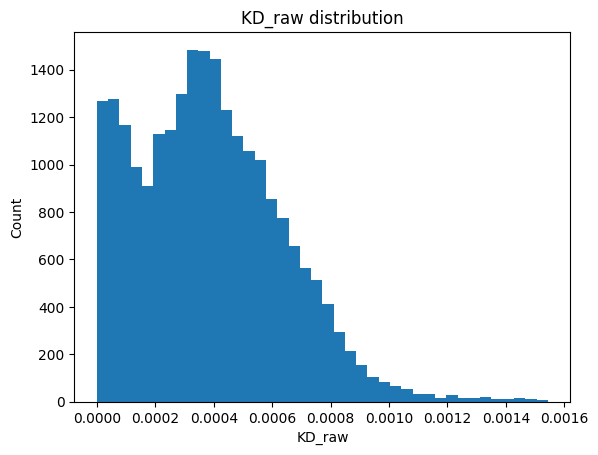

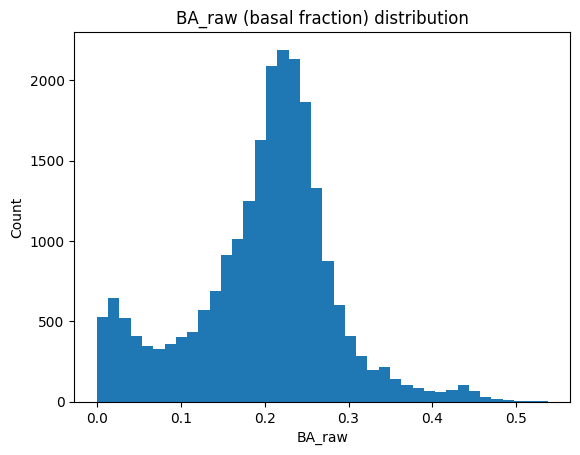

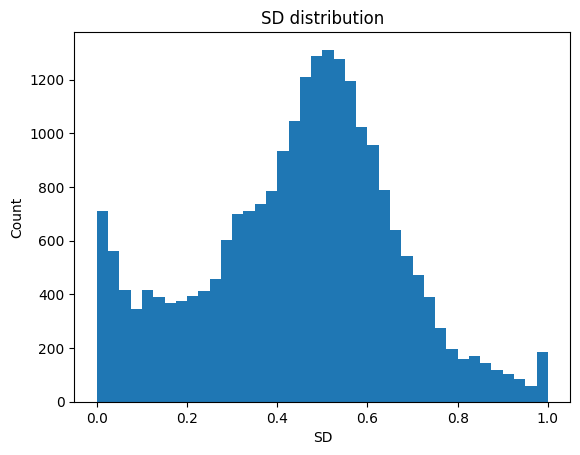

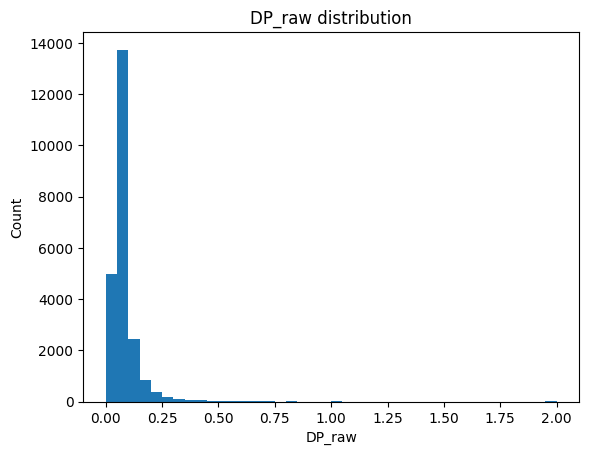

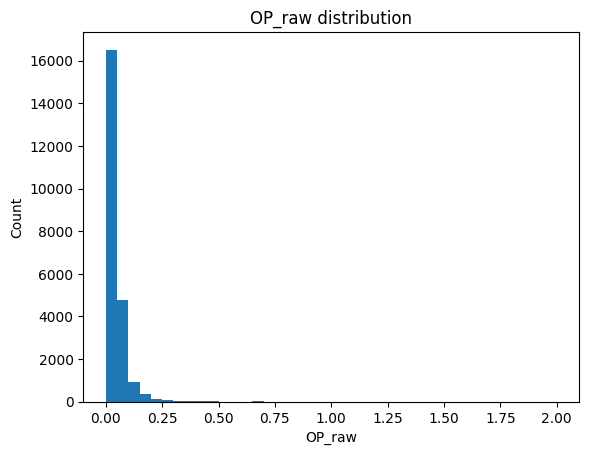

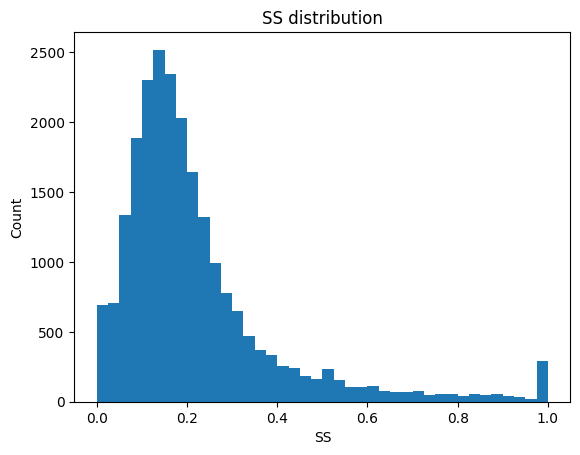

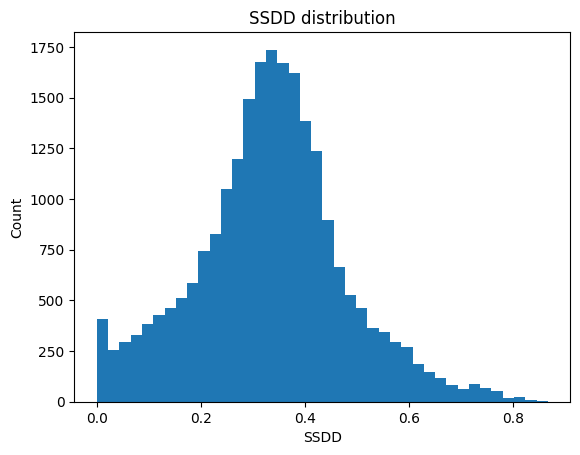

In [9]:
#QA plots

if MAKE_QA_PLOTS:
    qa_hist(bld["KD_raw"], "KD_raw distribution")
    qa_hist(bld["BA_raw"], "BA_raw (basal fraction) distribution")
    qa_hist(bld["SD"], "SD distribution")

    qa_hist(bld["DP_raw"], "DP_raw distribution")
    qa_hist(bld["OP_raw"], "OP_raw distribution")
    qa_hist(bld["SS"], "SS distribution")

    qa_hist(bld["SSDD"], "SSDD distribution")


In [10]:
# ======================
# Save packaged outputs
# ======================
#
# Writes:
#  - GeoPackage (recommended, stable, open format)
#  - CSV (no geometry)
#  - Run summary .txt
#
# Notes:
#  - Shapefile is not recommended for outputs because it truncates field names
#    and has type limitations. GeoPackage is the best open alternative.
#

import os
import time

os.makedirs(OUT_DIR, exist_ok=True)

# Build a run tag that encodes your key parameters
run_tag = (
    f"SDr{int(r_D)}_SSr{int(r_S)}_"
    f"aD{alpha_D:.2f}_aS{alpha_S:.2f}_b{beta:.2f}_"
    f"sig{sigma_theta:.0f}_eps{epsilon:.1f}_"
    f"norm{NORM_METHOD}"
)

out_gpkg = os.path.join(OUT_DIR, f"{RUN_NAME}_SSDD_{run_tag}.gpkg")
out_csv  = os.path.join(OUT_DIR, f"{RUN_NAME}_SSDD_{run_tag}.csv")
out_txt  = os.path.join(OUT_DIR, f"{RUN_NAME}_SSDD_{run_tag}_RunSummary.txt")

# Drop helper geometry columns that some drivers may not like
out_gdf = bld.drop(columns=["rep_pt"], errors="ignore").copy()

# Save GeoPackage
out_gdf.to_file(out_gpkg, layer="buildings_ssdd", driver="GPKG")

# Save CSV (no geometry)
# Include whatever fields are present; this list covers your core outputs.
csv_cols = [
    "bld_id",
    "KD_raw", "BA_raw", "KD", "BA", "SD",
    "DP_raw", "OP_raw", "DP", "OP", "SS", "SS_neighbors",
    "SSDD", "SSDD_geom",
    "SD_r_m", "SS_r_m",
    "alpha_D", "alpha_S", "beta",
    "sigma_th", "eps_m",
    "kernel", "w_area",
    "norm", "p_low", "p_high",
]

# Only write columns that exist (prevents accidental KeyErrors if you rename something)
csv_cols_existing = [c for c in csv_cols if c in out_gdf.columns]
out_gdf[csv_cols_existing].to_csv(out_csv, index=False)

# Save run summary
elapsed_sec = time.time() - t0 if "t0" in globals() else None

with open(out_txt, "w", encoding="utf-8") as f:
    f.write("SSDD run summary\n")
    f.write("----------------\n")
    f.write(f"RUN_NAME: {RUN_NAME}\n")
    f.write(f"INPUT: {INPUT_PATH} (layer={INPUT_LAYER})\n")
    f.write(f"N buildings: {len(out_gdf):,}\n")
    f.write(f"CRS (analysis): {out_gdf.crs}\n\n")

    f.write("Parameters:\n")
    f.write(f"  SD radius r_D (m): {r_D}\n")
    f.write(f"  SS radius r_S (m): {r_S}\n")
    f.write(f"  alpha_D: {alpha_D}\n")
    f.write(f"  alpha_S: {alpha_S}\n")
    f.write(f"  beta: {beta}\n")
    f.write(f"  sigma_theta (deg): {sigma_theta}\n")
    f.write(f"  epsilon (m): {epsilon}\n")
    f.write(f"  kernel: {kernel_type}\n")
    f.write(f"  weight_by_area: {weight_by_area}\n")
    f.write(f"  normalization: {NORM_METHOD} (P_LOW={P_LOW}, P_HIGH={P_HIGH})\n\n")

    f.write("Outputs:\n")
    f.write(f"  GPKG: {out_gpkg} (layer=buildings_ssdd)\n")
    f.write(f"  CSV : {out_csv}\n\n")

    if elapsed_sec is not None:
        f.write(f"Elapsed seconds: {elapsed_sec:.2f}\n")

print("Wrote:", out_gpkg)
print("Wrote:", out_csv)
print("Wrote:", out_txt)


Wrote: C:\Users\shoang12\OneDrive - Cal Poly\SSDD\output\SLO_sample_SSDD_SDr100_SSr50_aD0.50_aS0.50_b0.50_sig15_eps0.5_normrobust.gpkg
Wrote: C:\Users\shoang12\OneDrive - Cal Poly\SSDD\output\SLO_sample_SSDD_SDr100_SSr50_aD0.50_aS0.50_b0.50_sig15_eps0.5_normrobust.csv
Wrote: C:\Users\shoang12\OneDrive - Cal Poly\SSDD\output\SLO_sample_SSDD_SDr100_SSr50_aD0.50_aS0.50_b0.50_sig15_eps0.5_normrobust_RunSummary.txt


In [11]:
# ============================================================
# BATCH RUN: 4 separation thresholds (5, 10, 20, 30 m)
# ============================================================

import os, math, time
import numpy as np
from tqdm.auto import tqdm

separation_thresholds = [5, 10, 20, 30]  # meters

for threshold in separation_thresholds:
    print(f"\n{'='*50}")
    print(f"Running r_S = {threshold} m...")
    print(f"{'='*50}")

    # Set the separation radius for this run
    r_S_run = float(threshold)

    # --- Recompute SS terms ---
    dp_raw = np.zeros(len(bld), dtype=float)
    op_raw = np.zeros(len(bld), dtype=float)
    m_cnt  = np.zeros(len(bld), dtype=int)

    def compute_SS_terms_run(i):
        Pi = polys[i]
        phi_i = float(bld.iloc[i]["phi_deg"])
        idxs = tree_query_indices(tree_polys, Pi.buffer(r_S_run))
        inv_sum = 0.0
        inv_orient_sum = 0.0
        m = 0
        for j in idxs:
            if j == i:
                continue
            dij = Pi.distance(polys[j])
            if dij > r_S_run:
                continue
            inv = 1.0 / (dij + epsilon)
            phi_j = float(bld.iloc[j]["phi_deg"])
            theta = angle_difference_deg(phi_i, phi_j)
            orient = orientation_factor(theta, sigma_theta)
            inv_sum += inv
            inv_orient_sum += orient * inv
            m += 1
        if m == 0:
            return 0.0, 0.0, 0
        return inv_sum / m, inv_orient_sum / m, m

    for i in tqdm(range(len(bld)), desc=f"SS terms r_S={threshold}m"):
        dp_raw[i], op_raw[i], m_cnt[i] = compute_SS_terms_run(i)

    bld["DP_raw"] = dp_raw
    bld["OP_raw"] = op_raw
    bld["SS_neighbors"] = m_cnt

    bld["DP"] = norm_series(bld["DP_raw"], method=NORM_METHOD, p_low=P_LOW, p_high=P_HIGH)
    bld["OP"] = norm_series(bld["OP_raw"], method=NORM_METHOD, p_low=P_LOW, p_high=P_HIGH)
    bld["SS"] = alpha_S * bld["DP"] + (1 - alpha_S) * bld["OP"]

    # --- Recompute SSDD ---
    bld["SSDD"] = beta * bld["SD"] + (1 - beta) * bld["SS"]
    bld["SSDD_geom"] = np.sqrt(bld["SD"] * bld["SS"])

    # Add provenance columns
    bld["SD_r_m"]   = r_D
    bld["SS_r_m"]   = r_S_run
    bld["alpha_D"]  = alpha_D
    bld["alpha_S"]  = alpha_S
    bld["beta"]     = beta
    bld["sigma_th"] = sigma_theta
    bld["eps_m"]    = epsilon
    bld["kernel"]   = kernel_type
    bld["w_area"]   = weight_by_area
    bld["norm"]     = NORM_METHOD
    bld["p_low"]    = P_LOW
    bld["p_high"]   = P_HIGH

    # --- Save GPKG ---
    os.makedirs(OUT_DIR, exist_ok=True)
    out_gpkg = os.path.join(OUT_DIR, f"{RUN_NAME}_SSDD_sep{threshold}m.gpkg")
    out_gdf = bld.drop(columns=["rep_pt"], errors="ignore").copy()
    out_gdf.to_file(out_gpkg, layer="buildings_ssdd", driver="GPKG")
    print(f"Wrote: {out_gpkg}")

print("\nAll 4 runs complete.")


Running r_S = 5 m...


SS terms r_S=5m: 100%|█████████████████████████████████████████████████████████| 22974/22974 [00:03<00:00, 6300.56it/s]


Wrote: C:\Users\shoang12\OneDrive - Cal Poly\SSDD\output\SLO_sample_SSDD_sep5m.gpkg

Running r_S = 10 m...


SS terms r_S=10m: 100%|████████████████████████████████████████████████████████| 22974/22974 [00:04<00:00, 4674.13it/s]


Wrote: C:\Users\shoang12\OneDrive - Cal Poly\SSDD\output\SLO_sample_SSDD_sep10m.gpkg

Running r_S = 20 m...


SS terms r_S=20m: 100%|████████████████████████████████████████████████████████| 22974/22974 [00:07<00:00, 3083.15it/s]


Wrote: C:\Users\shoang12\OneDrive - Cal Poly\SSDD\output\SLO_sample_SSDD_sep20m.gpkg

Running r_S = 30 m...


SS terms r_S=30m: 100%|████████████████████████████████████████████████████████| 22974/22974 [00:11<00:00, 1984.07it/s]


Wrote: C:\Users\shoang12\OneDrive - Cal Poly\SSDD\output\SLO_sample_SSDD_sep30m.gpkg

All 4 runs complete.
